# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 2. Градиентный спуск своими руками

### Общая информация

Дата выдачи: 09.02.2026

Мягкий дедлайн: 23.02.2026 23:59 MSK

Жесткий дедлайн: 01.03.2026 23:59 MSK


### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). **Максимально допустимая оценка за работу — 10 баллов + 0.5 за социальный бонус.**

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Формат сдачи

Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием, а также файлы `descents.py` и `linear_regression.py`. Сам ноутбук называйте в формате **homework-practice-02-gd-Username.ipynb**, где Username - ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

**Оценка**: 10 + 0.5


### О задании

В данном задании необходимо реализовать обучение линейной регрессии с помощью различных модификаций градиентного спуска. В файле `descents.py` вам нужно будет реализовать несколько классов для различных вариаций градиентного спуска, а именно:
* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `SAGDescent`
* `MomentumDescent`
* `Adam`


В файле `linear_regression.py` вам необходимо будет реализовать класс `CustomLinearRegression` для обучения линейной регрессии (и, разумеется, предсказания целевой переменной на основе обученной модели).


### Про предложенную архитектуру

Предложенная вам архитектура шаблонов написана по принципам SOLID: основная ее идея в том, что вы сможете использовать различные лоссы и оптимизаторы с одним и тем же кодом прочих классов, никак не изменяя и не переписывая методы классов, которые с оптимизаторами и лоссом взаимодействуют. Мы добиваемся этого при помощи выделения интерфейсов (в Python мы достигаем этого при помощи абстрактных классов, см дальше в заданиях) и выделения зон ответственности каждого класса.

Глобально в нашей архитектуре всего 4 интерфейса (некоторые из которых на самом деле сразу concrete классы), каждый из которых порождает одно семейство:
- `interfaces.LossFunction`
  - Классы, имплементирующие этот интерфейс, отвечают за одну конкретную функцию потерь, используемую при обучении, и всё, что меняется вместе с ней при её замене: подсчёт лосса, подсчет градиента и аналитическое решение (если есть, то добавляется в интерфейс соответствующим mixin-ом).
- `interfaces.LinearRegressionInterface`
  - Интерфейс обертки для модели линейной регрессии, контейнер, содержащий составные части (лосс-функцию и оптимизатор) и использующий их для выполнения содержательной работы.
- `interfaces.LearningRateSchedule`
 - Простенькое семейство расписаний, определяющих шаг обучения для каждой итерации
- `interfaces.AbstractOptimizer`.
  -  Классы, имплементирующие этот интерфейс, имплементируют конкретный алгоритм оптимизации и всё, что происходит в его процессе. Пользуются обёрткой линейной регрессии для доступа к данным и вызова расчетов, чтобы не зависеть напрямую от конкретных функций потерь и шедулеров шага обучения.

Концепция передачи маленьких объектов, отвечающих за свою маленькую зону ответственности внутрь более сложного объекта для выполнения ими составных частей работы называется Dependency Injection, и работает как раз за счет выделения зоны ответственности и опоры на интерфейс вместо реализации.

Посмотрите на код `linear_regression.CustomLinearRegression`: она принимает в себя объекты с интерфейсами `LossFunction` и `AbstractOptimizer`, а в `descents.BaseDescent` как уточнении интерфейса абстрактного оптимизатора до итеративных оптимизаторов видно, что он в свою очередь принимает при инициализации объект шедулера шага обучения.

Благодаря этому, код, который использует эти классы, может по очереди:
- Инициализировать нужный шедулер с нужными параметрами для задания шага обучения
- Иницализировать оптимизатор, задав ему нужные параметры процесса и передав готовый шедулер
- Инициализировать класс линейной регрессии нужной под задачу функцией потерь и уже готовым оптимизатором.
- Запустить процесс обучения

И на любом этапе можно использовать другой объект с подходящим интерфейсом, и всё будет работать!


**В ходе выполнения этой домашки вы наполните все эти семейства классов различными имплементациями и будете менять их на ходу как перчатки!**

Более подробно про наследование классов в Python можно прочитать здесь:
* Наследование: https://docs.python.org/3/tutorial/classes.html#inheritance
* Абстрактные классы: https://docs.python.org/3/library/abc.html



## Задание 1. Линейная регрессия  (1 балл)

### Градиент функции потерь MSE

На семинаре про [матрично-векторное дифференцирование](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem03-vector-diff.pdf) вы должны были обсуждать дифференцирование функции потерь MSE в матричном виде.

### Задание 1.0. Градиент MSE в матричном виде (0.3 балла).

Напомним, что функция потерь MSE записывается как:

$$
    Q(w) = \frac{1}{\ell} \sum \limits_{i = 1}^\ell (y_i - \langle x_i, w \rangle)^2 = \frac{1}{\ell} \| X w - y \|^2
$$

где $\ell$ – количество объектов в выборке, $X \in \mathbb{R}^{\ell \times d}$ – матрица "объект-признак", а $y \in \mathbb{R}^\ell$ – целевая переменная. Через $x_i$ обозначается $i$-ая строчка матрицы $X$, отвечающая за $i$-й объект выборки.

- **Выпишите ниже (подсмотрев в семинар или решив самостоятельно) градиент для функции потерь MSE в матричном виде.**

**Решение:**

$\nabla Q(w) = \frac{2}{\ell} X^T (Xw - y)$


- **Имплементируйте методы `MSELoss.loss`, `MSELoss.gradient`**





### Задание 1.1 Аналитическое решение и `CustomLinearRegression` (0.7 балла)

Перед тем, как мы углубимся в итеративные методы оптимизации, давайте вспомним, что для ряда функций потерь существует и аналитическое решение. Давайте сперва вспомним, как оно выглядит для MSE.

- **Выведите формулу оптимальных $w$ в задаче минимизации MSE, и запишите её ниже.**

- **Имплементируйте подсчет этого решения в `MSELoss._plain_analytic_solution`**

$$\text{MSE} = \| X w - y \|^2$$
$$ w = (X^T X)^{-1} X^T y $$

**Вопрос**: Как мы помним, у аналитического решения есть минусы - какие?

**Ответ**:
1. Не всегда работает, поскольку требуется обратимость (если есть мультиколлинеарность, то все грустно)
2. Долго, поскольку высокая сложность алгоритма нахождения обратной матрицы (куб)

Теперь прокинем это решение в наш класс линейной регрессии, чтобы получше разобраться в архитектуре.


- **Допишите класс `descents.AnalyticSolutionOptimizer`**
- **Допишите класс `CustomLinearRegression`**
  - В нем на текущем этапе нужно имплементировать все методы: `fit` и `predict` вам понадобятся прямо сейчас, а `compute_gradients` и `compute_loss` в следующей части.

Помните, про разделение ответственности классов!

За контроль процесса обучения отвечает оптимизатор, а объект линейной регрессии по факту выступает точкой входа, контейнером для данных и способом доступа к вычислениям, на основе которых оптимизатор принимает решения (e.g. значение антиградиента в точке весов).

При этом сам по себе оптимизатор должен быть универсален, в нем никак не должны содержаться детали, связанные с конкретными функциями потерь, все необходимое от них он может получить через `self.model`.

Аналогично, класс линейной регрессии тоже должен быть универсальным и готовым к работе с любыми лоссами и оптимизаторами, исполняющими заявленный интерфейс. Здесь применена dependency injection, и вы должны грммотно ее поддержать в своей имплементации. Аналогично, все, что вам может быть нужно от функций потерь, вы можете получить при помощи обращения к переданному объекту.

In [1]:
import numpy as np
from linear_regression import MSELoss, CustomLinearRegression, AnalyticSolutionOptimizer

num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

c:\Python Projects\Jupyter\ml\linear_regression.py:126: SyntaxWarning: invalid escape sequence '\h'
  """


In [2]:
from sklearn.metrics import mean_squared_error as mse
import sklearn

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"

Sklearn MSE 0.1132685797898854
Your MSE 0.11326857978988542


Давайте сделаем задание немного прикольнее и изменим одну из колонок. Как мы знаем, полная мультиколлинеарность запрещает нам пользоваться аналитическим решением, но `sklearn` по какой-то причине это обходит, хмм

In [3]:
x[:, 3] = x[:, 2] + x[:, 4]

In [4]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

Sklearn MSE 0.11580190762483399
Your MSE 1.2760390909451562


Ваша задача - понять, как можно сделать так, чтобы аналитическое решение работало всегда, вне зависимости от матрицы X. Как оказывается, это можно сделать, если воспользоваться SVD разложением. Для имплементации воспользуйтесь `scipy.sparse.linalg.svds`.

- Выведите через SVD формулу оптимальных $w$ в задаче минимизации MSE.

- Имплементируйте подсчет этого решения в `MSELoss._svd_analytic_solution`
    - Мир итерационных агоритмов причудлив. Если вы посмотрите на опции солверов svds, то увидите, что возможности вычислить точно все сингулярные числа вам не дают (propack рандомизированный и даст вам неточные ответы). Используйте стандартный солвер, выставьте максимальную доступную точность.

- Ответьте на **вопрос на засыпку**. Вообще говоря, в ряде случаев (например в нашем), даже такая неабсолютная на первый взгляд точность все равно позволяет получить точное решение задачи. Обоснуйте, почему? Как называется такой вид SVD? Какого минимального числа сингулярных чисел с вероятностью 1 будет достаточно в нашем случае для получения точного решения? Обоснуйте, почему.


$$\text{X} = \underset{n\times m}{\mathrm{U}} \ \underset{m\times m}{\mathrm{\Sigma}} \ \underset{m\times k}{\mathrm{V^T}}$$
$$ w = V \Sigma^+ U^T y, \quad \text{где } \Sigma^+ = \operatorname{diag}(1/\sigma_1, \dots, 1/\sigma_r, 0, \dots, 0) $$

**Ответ**:
1. Ненулевые сингулярные значения определяют решение, а остальные 0, что не влияет на решение. Тогда если мы отбросим 0, то ничего не поменяется. + Сами сингулярные значения расположены по убыванию и чем они меньше, тем менее значительный вес имеют в решении. Поэтому мы можем опускать самые правые сингулярные значения, не особо теряя в точности.
2. Усеченное SVD
3. Ранг матрицы, т.к. это ровно все ненулевые сингулярные значения, поэтому мы получим точное решение

In [5]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))


your_linreg =  CustomLinearRegression(AnalyticSolutionOptimizer(),
                                      loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution))
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"

Sklearn MSE 0.11580190762483399
Your MSE 0.11580190762483399


## Задание 2. Реализация градиентного спуска (4 балла)

В этом задании вам предстоит написать собственные реализации различных подходов к градиентному спуску с опорой на подготовленные шаблоны в файле `descents.py`. При помощи них мы будем искать итеративные решения, подавая оптимизаторы внутрь нашей `CustomLinearRegression`.

### Напоминание про градиентный спуск

Основное свойство антиградиента &ndash; он указывает в сторону *наискорейшего* убывания функции в данной точке. Соответственно, будет логично стартовать из некоторой точки, сдвинуться в сторону антиградиента,
пересчитать антиградиент и снова сдвинуться в его сторону и т.д. Запишем это более формально.

Пусть $w_0$ &ndash; начальный набор параметров (например, нулевой или сгенерированный из некоторого
случайного распределения). Тогда ванильный градиентный спуск состоит в повторении следующих шагов до сходимости:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь $\eta_{k}$ обозначает длину шага на $k$-ой итерации (learning rate), а $Q(w)$ - функцию потерь (loss function).

Градиент для MSE вы уже нашли выше

### Задание 2.0. Learning Rate Schedules (0.2 балла)

Обратите внимание на **абстрактный** класс `LearningRateSchedule` в файле `descents.py`. С помощью его имплементаций мы на каждой итерации градиентного спуска будем получать соответствующий `learning_rate` $\eta_k$.

В файле уже реализован класс `ConstantLR`, который на каждой итерации возвращает один и тот же заранее заданный шаг. **Ваша задача в этом пункте – реализовать `TimeDecayLR`**, который мы будем использовать для обучения линейной регрессии. Формула очередного шага должна выглядеть следующим образом:
$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

### Задание 2.1. Родительский класс BaseDescent (1 балл).


Внимательно изучите устройство класса `BaseDescent`. У него есть один непомеченный абстрактным метод, который ему как частичному наследнику абстрактного класса нужно имплементировать - это `optimize`. В
этом методе необходимо имплементировать основной цикл обучения, и далее его будут переиспользовать все его наследники.

- **Допишите метод `BaseDescent.optimize`**


Для этого и всех дальнейших заданий необходимо соблюдать следующие условия:

* **Все вычисления должны быть векторизованы;**
* Циклы средствами python допускаются только для итераций градиентного спуска;
* В качестве критерия останова необходимо использовать (одновременно):
    * Квадрат евклидовой нормы разности весов на двух соседних итерациях меньше `tolerance`;
    * Разность весов содержит наны;
    * Достижение максимального числа итераций `max_iter`.
* Будем считать, что все данные, которые поступают на вход имеют столбец единичек последним столбцом;
* Веса модели надо обновлять внутри функции `_update_weights`, она неспроста так называется
* Чтобы проследить за сходимостью оптимизационного процесса будем использовать `CustomLinearRegression.loss_history`, в нём будем хранить *значения функции потерь до каждого шага, начиная с нулевого* (до первого шага по антиградиенту) и *значение функции потерь после оптимизации*.


Обратите внимание, что метод `_update_weights` всё ещё является абстрактным - его все ещё должны будут имплементировать дальнейшие наследники; фактически, только способом обновления весов они и отличаются. Она должна должна обновлять веса модели `self.model.w`, а также возвращать величину обновления $w_{k + 1} - w_k$.

Также обратите внимание на атрибут `self.iteration`, отвечающий за номер итерации алгоритма спуска. Как раз с помощью него (и `self.lr_schedule`) мы и будем получать `learning_rate` на соответствующей итерации алгоритма.

**Обратите внимание**

*да, в третий раз*

Все реализуемые вами классы спуска в задании - это *универсальные* оптимизаторы. Они не должны считать градиенты конкретной функции потерь внутри себя.

Для вычисления градиента они всегда обращаются к модели, с которой работают:

```
gradient = self.model.compute_gradients(X_batch, y_batch)
```

### Задание 2.2. Полный градиентный спуск VanillaGradientDescent (0.6 балла).

Реализуйте полный градиентный спуск заполнив пропуски в классе `VanillaGradientDescent` в файле `descents.py`. Напомним, что шаг классического градиентного спуска выглядит следующим образом:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

**Важно**: Здесь и далее функция `_update_weights` должна возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$. Кроме того, соответственно своему названию, она должна обновлять веса модели `model.w`.

### Напоминание про SGD (стохастических градиентный спуск)

Как правило, в задачах машинного обучения функционал $Q(w)$ представим в виде суммы $\ell$ функций:

$$
    Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        q_i(w).
$$

В нашем домашнем задании отдельные функции $q_i(w)$ соответствуют ошибкам на отдельных объектах.

Проблема метода градиентного спуска состоит в том, что на каждом шаге необходимо вычислять градиент всей суммы (будем его называть полным градиентом):

$$
    \nabla_w Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        \nabla_w q_i(w).
$$

Это может быть очень трудоёмко при больших размерах выборки. В то же время точное вычисление градиента может быть не так уж необходимо &ndash; как правило, мы делаем не очень большие шаги в сторону антиградиента, и наличие в нём неточностей не должно сильно сказаться на общей траектории.

Оценить градиент суммы функций можно средним градиентов случайно взятого подмножества функций:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}),
$$
где $B$ - это случайно выбранное подмножество индексов, обычно называемое **батчом**.

Оценка $\frac{1}{|B|} \sum \limits_{i \in B} \nabla_w q_i(w_k)$ называется **стохастическим градиентом** функции потерь, а получившийся метод называют методом **стохастического градиентного спуска** или просто SGD.

### Задание 2.3. Стохастический градиентный спуск StochasticGradientDescent (0.7 балла).

Реализуйте стохастический градиентный спуск, заполнив пропуски в классе `StochasticGradientDescent`. Для оценки градиента используйте формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться **гиперпараметром** метода и передаваться в конструктор класса `__init__(...)`. Семплировать индексы батча объектов $B$ можно с повторениями (через np.random.randint) - это допустимо и даёт несмещённую оценку градиента. По желанию можно без повторений (np.random.choice(..., replace=False) или через пермутацию по эпохам).

### Задание 2.4 Stochastic Average Gradient (0.6 балла)

Держим память последних индивидуальных градиентов $g_i$ по всем объектам и их среднее $\bar g = \frac{1}{\ell}\sum_i g_i$. На каждом шаге выбираем индексы $j$ (мини-батч), заново считаем $g_j^{new}(w_k)$, обновляем среднее:
$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr),\qquad
w_{k+1} = w_k - \eta_k \bar g.
$$
Инициализация: $g_i=0 \Rightarrow \bar g=0$.

Так получаем шаг почти как у полного градиента, но считаем градиент лишь на нескольких объектах за итерацию.

Реализуйте класс `SAGDescent` в `descents.py` с хранением `grad_memory` и `avg_grad`. Подсказка: чтобы получить пер-объектный градиент, можно вызывать `compute_gradients` на срезе из одного объекта `X[j:j+1]` или на фильтрованной индексами матрице для батча.

**Имейте в виду, что SAG достаточно капризный**: для его сходимости (и ее скорости) достаточно важен размер батча. Для вас установлено дефолтное значение, но на реальных данных его может быть недостаточно. В сравнениях методов ниже вам может понадобится подобрать значение размера батча, чтобы раскрыть потенциал метода. То ж касается и SGD, но в меньшей степени.

### Напоминание про метод инерции (или метод моментов)

Может оказаться, что направление антиградиента сильно меняется от шага к шагу. Например, если линии уровня функционала сильно вытянуты, то из-за ортогональности градиента линиям уровня он будет менять направление на почти противоположное на каждом шаге. Такие осцилляции будут вносить сильный шум в движение, и процесс оптимизации займёт много итераций. Чтобы избежать этого, можно усреднять векторы антиградиента с нескольких предыдущих шагов &ndash; в этом случае шум уменьшится, и такой средний вектор будет указывать в сторону общего направления движения. Введём для этого вектор инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k})
\end{align}

Здесь $\alpha$ &ndash; параметр метода, определяющей скорость затухания градиентов с предыдущих шагов. Разумеется, вместо вектора градиента может быть использована его аппроксимация (например, в случае **стохастического градиентного спуска**). Чтобы сделать шаг градиентного спуска, просто сдвинем предыдущую точку на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Заметим, что если по какой-то координате градиент постоянно меняет знак, то в результате усреднения градиентов в векторе инерции эта координата окажется близкой к нулю. Если же по координате знак градиента всегда одинаковый, то величина соответствующей координаты в векторе инерции будет большой, и мы будем делать большие шаги в соответствующем направлении.

### Задание 2.5 Метод Momentum - MomentumDescent (0.5 балла).

Реализуйте градиентный спуск с методом инерции заполнив пропуски в классе `MomentumDescent`. Шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ являеться гиперпараметром метода, однако в данном домашнем задании мы зафиксируем её за вас $\alpha = 0.9$.

### Напоминание про AdaGrad, RMSprop и Adam

Градиентный спуск очень чувствителен к выбору длины шага. Если шаг большой, то есть риск, что мы будем перескакивать через точку минимума; если же шаг маленький, то для нахождения минимума потребуется много итераций. При этом нет способов заранее определить правильный размер шага &ndash; к тому же, схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad предлагается сделать свою длину шага для каждой компоненты вектора параметров. Идея проста: мы будем "копить" сумму квадратов градиентов и делить очередной градиент на корень из этой суммы. Таким образом, обновление весов с большими градиентами будет тормозиться, а с маленькими наоборот получать большие шаги. Формула обновлени будет выглядить так:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Здесь $\varepsilon$ небольшая константа, которая предотвращает деление на ноль.

В данном методе можно зафиксировать длину шага (например, $\eta_k = 0.01$) и не подбирать её в процессе обучения **(обратите внимание, что в данном домашнем задании длина шага не фиксируется)**. Отметим, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю. Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги; если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

У метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт, из-за чего шаги становятся всё медленнее и могут остановиться ещё до того, как достигнут минимум функционала. Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Можно объединить идеи описанных выше методов: накапливать градиенты со всех прошлых шагов для
избежания осцилляций (метод инерции), а также делать адаптивную длину шага по каждому параметру (`RMSProp`). Таким образом, мы получим метод `Adam` с той лишь разницей, что в методе `Adam` дополнительно делается нормировка накопленных градиентов и квадратов градиентов для устранения смещения.

### Задание 2.6. Метод Adam (Adaptive Moment Estimation) (0.4 балла).

Реализуйте градиентный спуск с методом Adam, заполнив пропуски в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы за вас.

## Задание 3. Проверка кода (0 баллов)

Данная секция нужна для того, чтобы убедиться в правильности реализации методов спуска и класса `CustomLinearRegression`. В начале мы сделаем небольшую локальную проверку на "адекватность" и "запускаемость" ваших моделей, после чего уже можно будет делать посылки в Яндекс Контест.

In [6]:
%load_ext autoreload

In [7]:
#%autoreload 2

from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)

from linear_regression import CustomLinearRegression

In [8]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

Проверяем код на запускаемость.

In [9]:
descent_models = [
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
   optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
   model = CustomLinearRegression(optimizer=optimizer)
   model.fit(x, y)
   assert len(model.loss_history) == max_iter + 1, "Loss history failed"
   y_pred = model.predict(x)
   assert y_pred.shape == y.shape, "Prediction shape does not match target variable"


Если ваше решение прошло все тесты локально, то теперь пришло время протестировать его в [Яндекс Контесте](https://new.contest.yandex.ru/contests/90083/start).

Для каждой задачи из контеста вставьте ID успешной посылки и ваш ник (почту):

* **Ник/почта**: dvperevalov@edu.hse.ru


* **VanillaGradientDescent**: 157817484 dvperevalov@edu.hse.ru


* **StochasticGradientDescent**: 157817536 dvperevalov@edu.hse.ru


* **SAGDescent**: 157817543 dvperevalov@edu.hse.ru


* **MomentumDescent**: 157817550 dvperevalov@edu.hse.ru


* **Adam**: 157817557 dvperevalov@edu.hse.ru


* **LinearRegression**: 157817573 dvperevalov@edu.hse.ru

## Задание 4. Работа с данными (1 балл)

Мы будем использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас будет являться цена.

* Постройте график распределения целевой переменной в данных, подумайте, нужно ли заменить её на логарифм. Присутствуют ли выбросы в данных с аномальной ценой? Если да, то удалите их из данных.

* Проведите исследование данных:
    * Проанализируйте тип столбцов, постройте графики зависимости целевой переменной от признака, распределения значений признака;
    * Подумайте (и напишите): какие признаки могут быть полезными на основе этих графиков, обработайте выбросы;
    * Подумайте (и напишите): какие трансформации признаков из известных вам будет уместно применить;
    * Разделите полезные признаки на категориальные, вещественные и те, которые не надо предобрабатывать.
* Разделите данные на обучающую, валидационную и тестовую выборки в отношении 8:1:1.

In [10]:
import numpy as np
import pandas as pd  # при желании, можете заменить на polars/pyspark или что угодно, что вам нравится

import matplotlib.pyplot as plt
import seaborn as sns

from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_regression import CustomLinearRegression

sns.set(style='darkgrid')

In [11]:
data = pd.read_csv('autos.csv')  # разумеется, если вы используете не pandas, это надо поменять

In [12]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

Разделите признаки на категориальные, числовые и ... все остальное

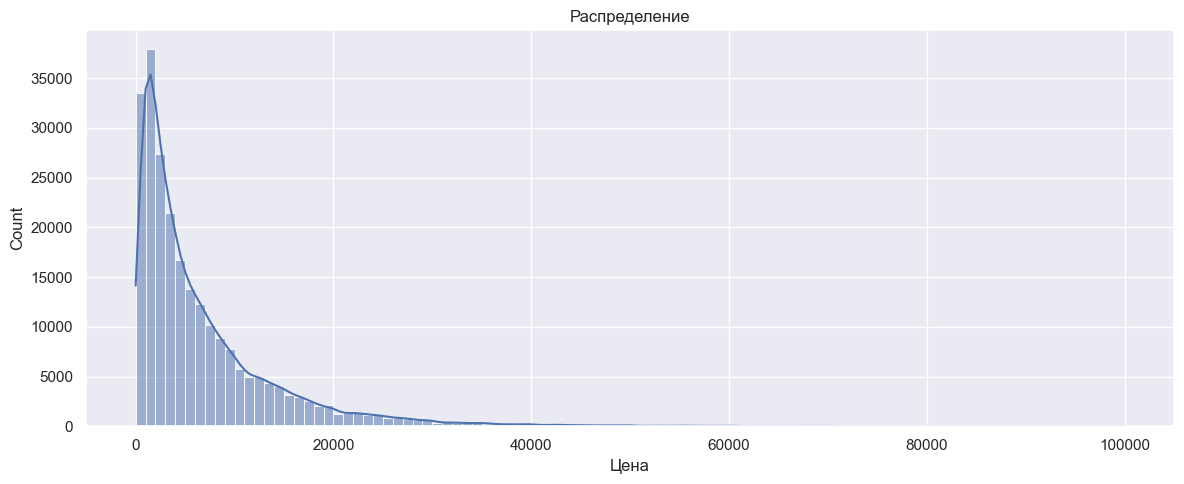

In [13]:
categorical = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
numeric = ['powerPS', 'kilometer', 'autoAgeMonths']
other = []
# price - не признак, это таргет

# YOUR CODE (EDA) HERE ٩(⁎❛ᴗ❛⁎)۶

plt.figure(figsize=(12, 5))

sns.histplot(data['price'], bins=100, kde=True)
plt.title('Распределение')
plt.xlabel('Цена')

plt.tight_layout()
plt.show()


1. Хочется обрезать цену где-то до 40000-50000, чтобы модель лучше обучалась. Ещё много авто с ценой ~1 напрягает Поэтому давайте я просто возьму и обрежу снизу и сверху даннные, оставив 2-98 перцентили. 
2. Логарифм позволит сделать данные более "гладкими", что хорошо повлияет на качество модели. 

In [14]:
data.describe()  # мне кажется, или авто с ценой 1 - это что-то странное

,powerPS,kilometer,autoAgeMonths,price
count,241190.000000,241190.000000,241190.000000,241190.000000
mean,131.271628,123766.677723,144.768676,6887.741892
std,60.622613,39825.955933,73.092598,8024.451993
min,51.000000,5000.000000,1.000000,1.000000
25%,90.000000,100000.000000,92.000000,1750.000000
50%,120.000000,150000.000000,140.000000,4100.000000
75%,160.000000,150000.000000,192.000000,8999.000000
max,589.000000,150000.000000,600.000000,99999.000000


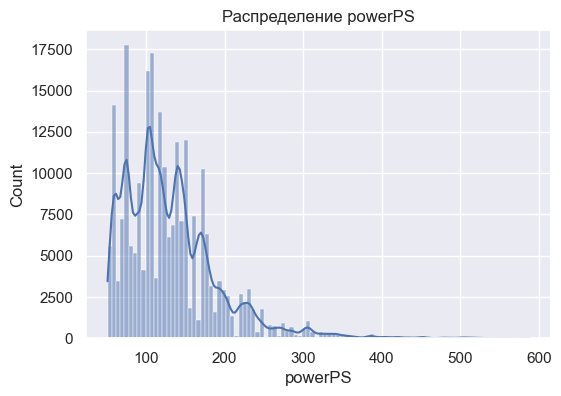

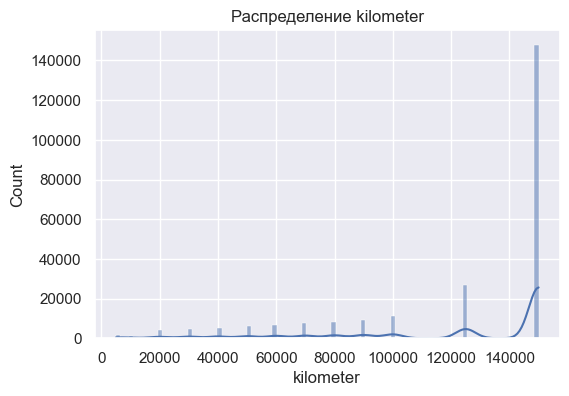

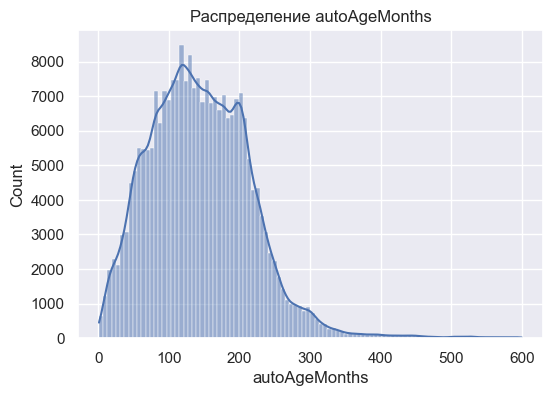

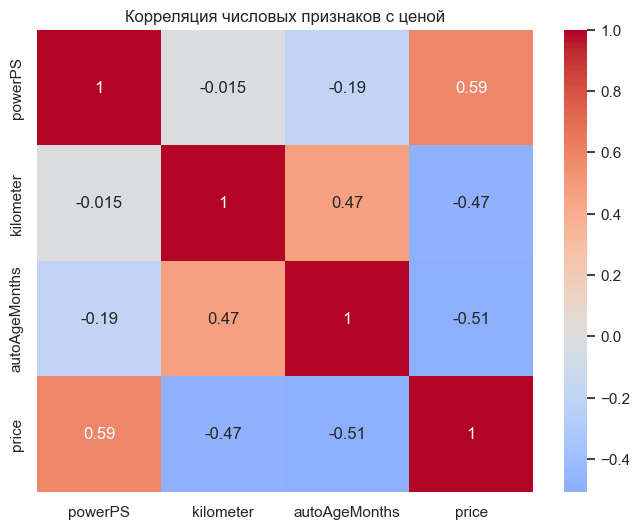

In [15]:
numbers = ['powerPS', 'kilometer', 'autoAgeMonths']

for col in numbers:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], bins=100, kde=True)
    plt.title(f'Распределение {col}')
    plt.show()

matrix = data[numbers + ['price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков с ценой')
plt.show()

Видим, что возраст машины и ее киллометраж коррелируют (логично), все числовые признаки довольно неплохо коррелируют с ценой, поэтому оставим их и посчитаем важными. В принципе по логике тут все норм. Непонятно только зачем делать киллометраж дискретным, но опустим это. Хочется немного подрезать данные, чтобы улучшить модель, например особо большие powerPS, или autoAgeMonths, kilometers оставим пока что как есть. 

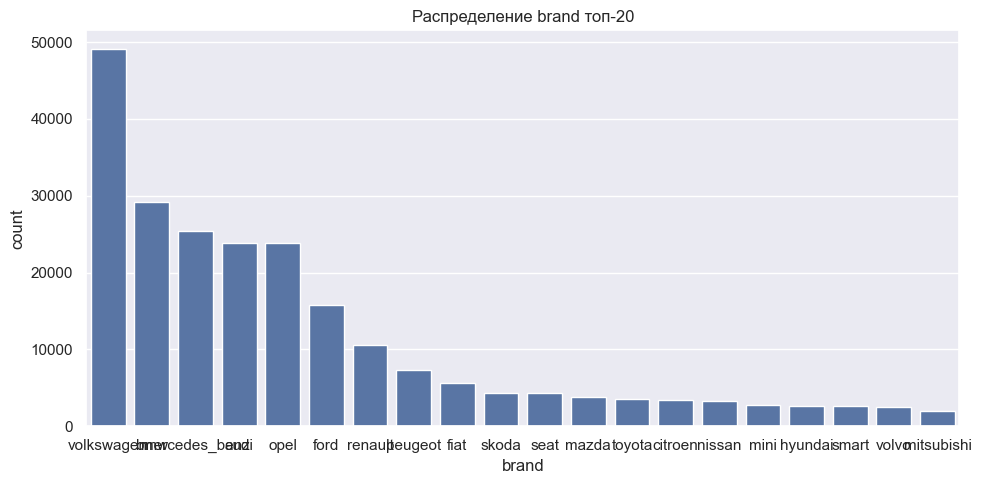

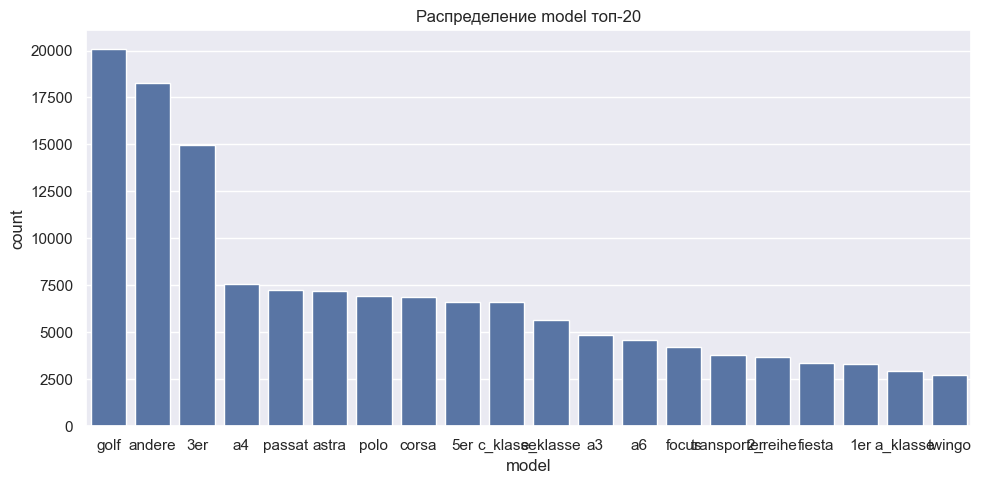

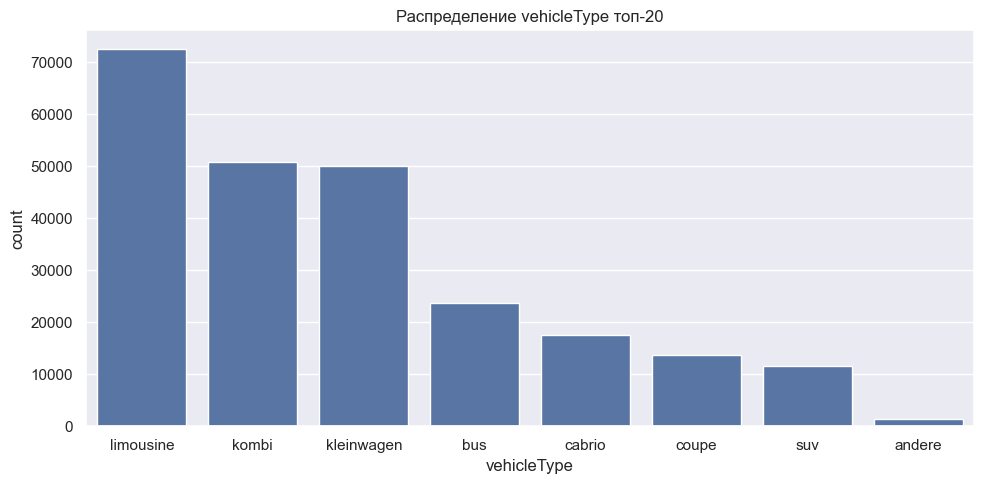

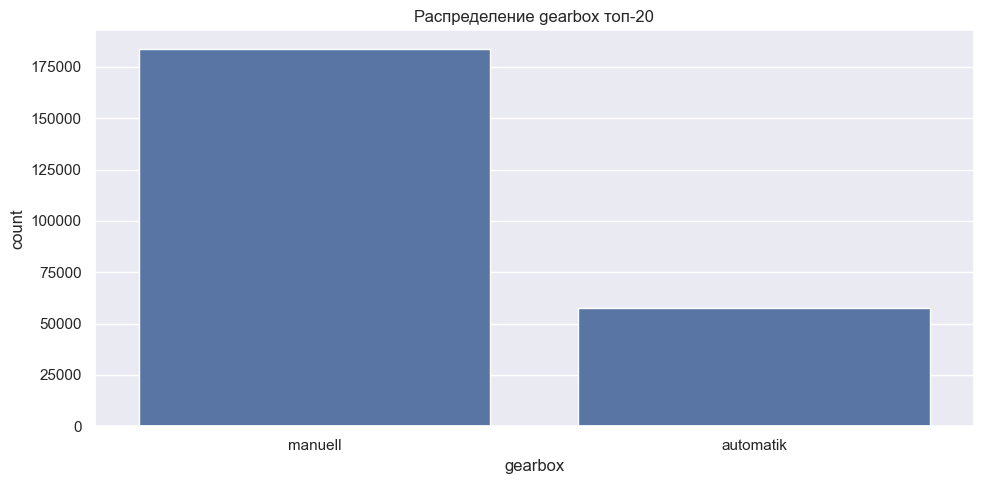

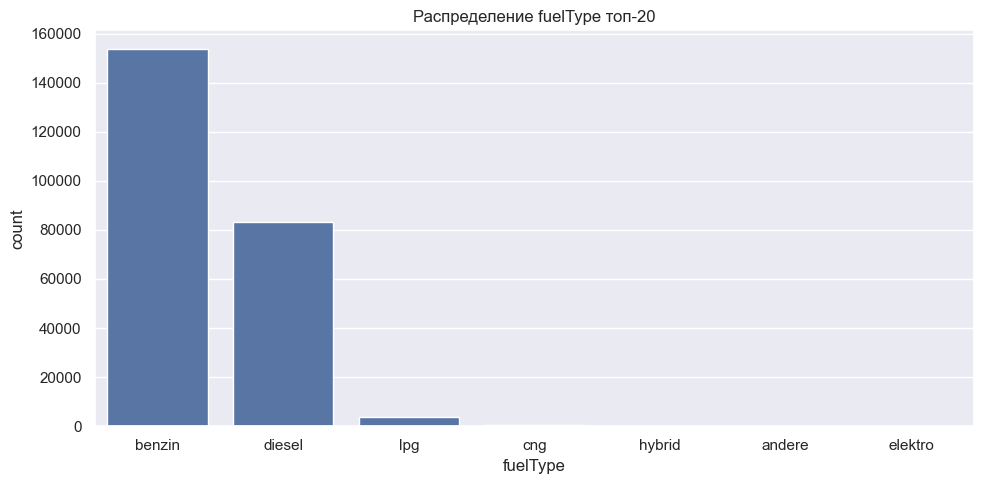

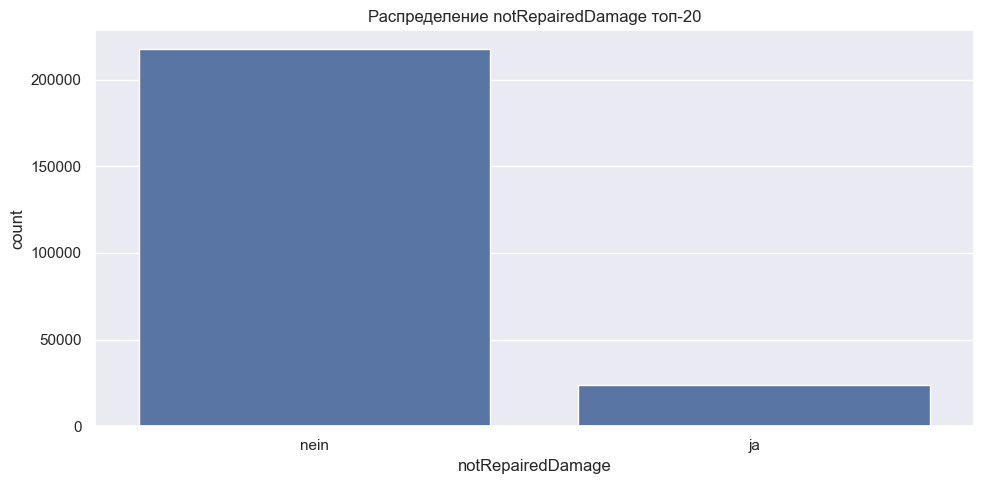

In [16]:
words = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']

for col in words:
    plt.figure(figsize=(10, 5))

    if data[col].nunique() > 20:
        top = data[col].value_counts().nlargest(20).index
        subset = data[data[col].isin(top)]
    else:
        subset = data

    sns.countplot(x=subset[col], order=subset[col].value_counts().index)
    plt.title(f'Распределение {col} топ-20')
    plt.tight_layout()
    plt.show()

Очень хочется фильтрануть по типу топлива, а то там почти вообще нет записей по некоторым типам

In [17]:
print(len(data[data['fuelType'] == 'andere']) + len(data[data['fuelType'] == 'hybrid']) + len(data[data['fuelType'] == 'elektro']) + len(data[data['fuelType'] == 'cng']))
print(len(data))

685
241190


Думаю, что эти записи ничего не испортят, но только улучшат ситуацию, если их убрать

In [18]:
low = data['price'].quantile(0.02)
high = data['price'].quantile(0.98)
data = data[(data['price'] >= low) & (data['price'] <= high)]

high = data['powerPS'].quantile(0.99)
data = data[data['powerPS'] <= high]

high = data['autoAgeMonths'].quantile(0.99)
data = data[data['autoAgeMonths'] <= high]

rare_fuels = ['andere', 'hybrid', 'elektro', 'cng']
data = data[~data['fuelType'].isin(['andere', 'hybrid', 'elektro', 'cng'])]

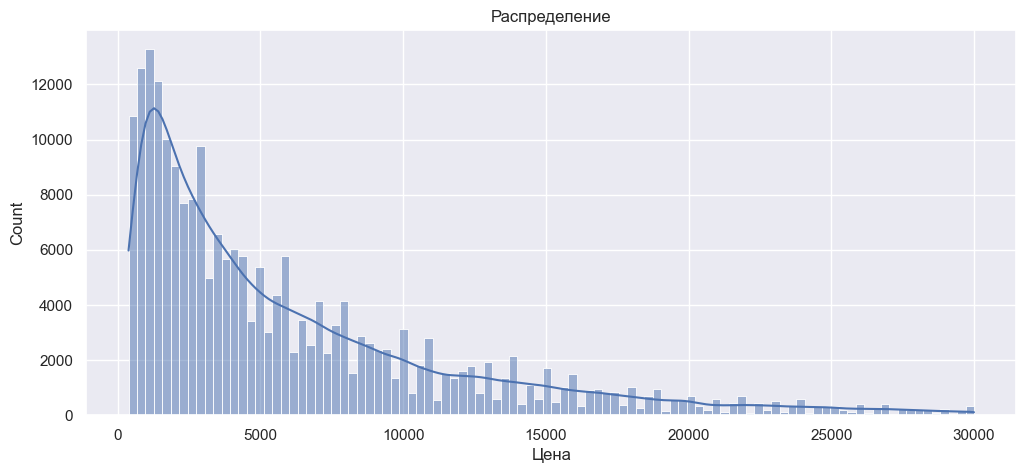

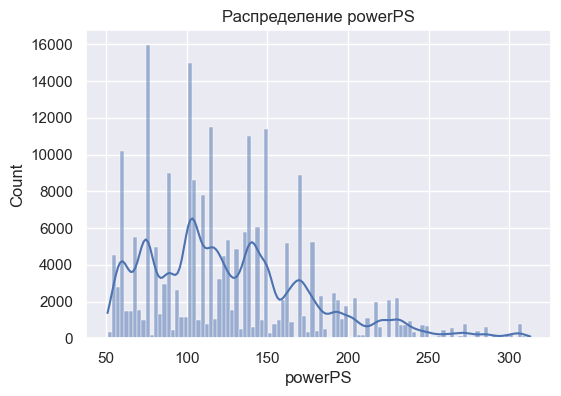

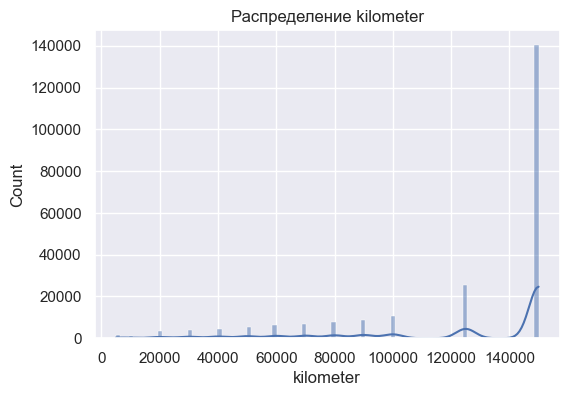

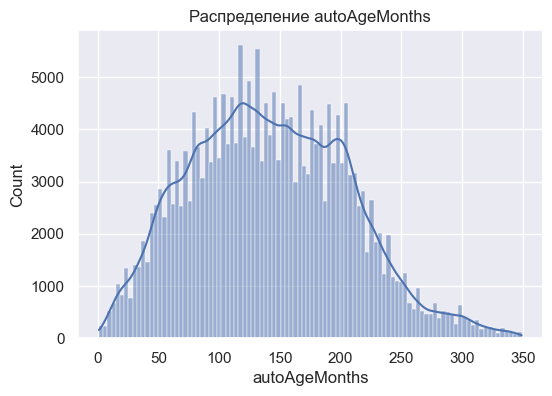

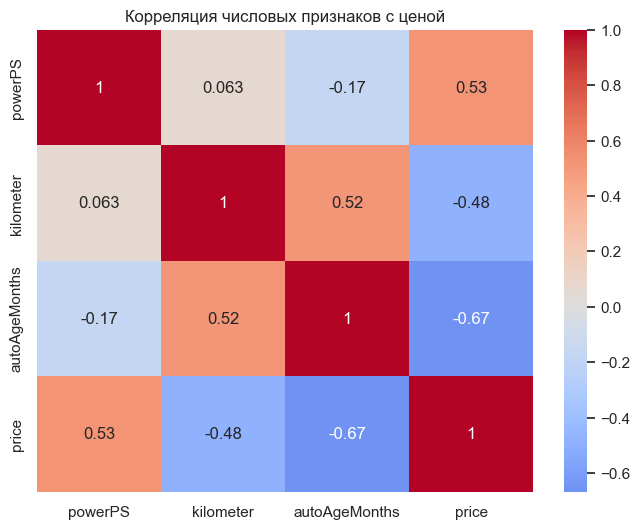

In [19]:
plt.figure(figsize=(12, 5))
sns.histplot(data['price'], bins=100, kde=True)
plt.title('Распределение')
plt.xlabel('Цена')

numbers = ['powerPS', 'kilometer', 'autoAgeMonths']

for col in numbers:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], bins=100, kde=True)
    plt.title(f'Распределение {col}')
    plt.show()

matrix = data[numbers + ['price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков с ценой')
plt.show()

In [20]:
data.describe()

,powerPS,kilometer,autoAgeMonths,price
count,226448.000000,226448.000000,226448.000000,226448.000000
mean,127.073151,124828.349113,141.985944,6173.409816
std,50.841603,38753.903273,65.199555,5917.081698
min,51.000000,5000.000000,1.000000,380.000000
25%,90.000000,100000.000000,93.000000,1800.000000
50%,116.000000,150000.000000,139.000000,4000.000000
75%,150.000000,150000.000000,189.000000,8500.000000
max,313.000000,150000.000000,349.000000,29999.000000


In [21]:
data.dtypes

brand                object
model                object
vehicleType          object
gearbox              object
fuelType             object
notRepairedDamage    object
powerPS               int64
kilometer             int64
autoAgeMonths         int64
price                 int64
dtype: object

In [22]:
# Хочется использовать OneHotEncoding для большинства
print(data['brand'].unique())
print('-'*50)
print(data['fuelType'].unique())
print('-'*50)
print(data['notRepairedDamage'].unique()) # хочется в булев превратить, но просят OneHotEncoding
print('-'*50)
print(data['vehicleType'].unique())
print('-'*50)
print(data['gearbox'].unique())
print('-'*50)
print(data['model'].unique()) # тут бывают модели с числовым названием

['volkswagen' 'skoda' 'bmw' 'peugeot' 'mazda' 'nissan' 'renault' 'ford'
 'mercedes_benz' 'honda' 'fiat' 'mini' 'smart' 'audi' 'subaru'
 'mitsubishi' 'hyundai' 'opel' 'alfa_romeo' 'seat' 'lancia' 'porsche'
 'citroen' 'toyota' 'kia' 'chevrolet' 'dacia' 'suzuki' 'daihatsu'
 'chrysler' 'volvo' 'jaguar' 'rover' 'jeep' 'saab' 'daewoo' 'land_rover'
 'lada']
--------------------------------------------------
['benzin' 'diesel' 'lpg']
--------------------------------------------------
['nein' 'ja']
--------------------------------------------------
['kleinwagen' 'limousine' 'cabrio' 'kombi' 'suv' 'bus' 'coupe' 'andere']
--------------------------------------------------
['manuell' 'automatik']
--------------------------------------------------
['golf' 'fabia' '3er' '2_reihe' '3_reihe' 'passat' 'navara' 'twingo'
 'c_max' 'a_klasse' 'scirocco' '5er' 'andere' 'civic' 'punto' 'e_klasse'
 'one' 'clio' '1er' 'b_klasse' 'fortwo' 'a8' 'jetta' 'c_klasse' 'micra'
 'vito' 'sprinter' 'escort' 'forester' 'f

In [23]:
print(data.isnull().sum())  # ура

brand                0
model                0
vehicleType          0
gearbox              0
fuelType             0
notRepairedDamage    0
powerPS              0
kilometer            0
autoAgeMonths        0
price                0
dtype: int64


In [24]:
data['kilometer'].unique()  # зачем они сделали это дискретным?

array([150000,  90000,  70000, 100000,  60000,  20000, 125000,  80000,
        50000,  40000,  10000,  30000,   5000])

In [25]:
# Логарифмируем цену, чтобы сделать норм распредеение для нее
data['price'] = np.log1p(data['price'])

Text(0.5, 0, 'Цена')

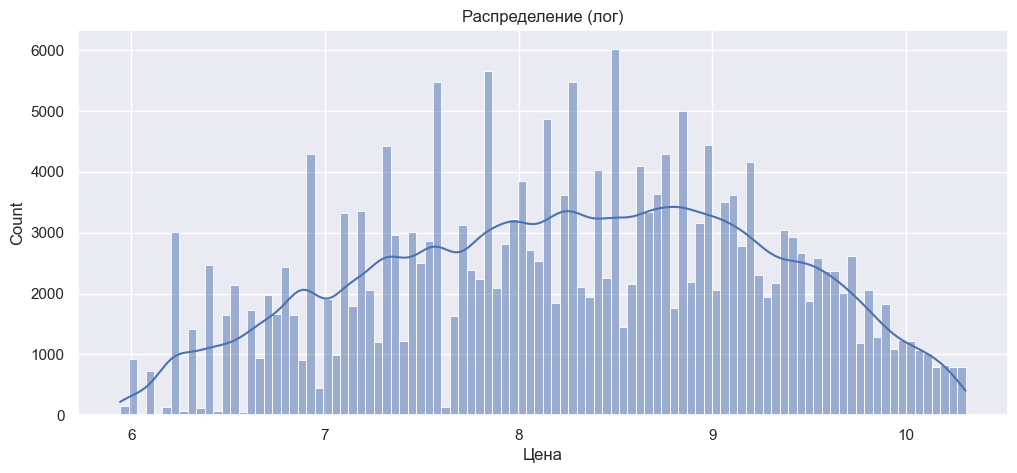

In [26]:
plt.figure(figsize=(12, 5))
sns.histplot(data['price'], bins=100, kde=True)
plt.title('Распределение (лог)')
plt.xlabel('Цена') # гораздо приятнее стала

Добавляем в данные единичную колонку `bias`, чтобы не делать отдельные параметр $b$ для свободного члена модели.

In [27]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['price']

Теперь вам необходимо разбить данные на обучающую, тестовую и валидационную выборки.

In [28]:
# YOUR CODE HERE ┌(ಠ_ಠ)┘
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test = train_test_split(
    x, y, test_size=0.1, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_val, y_val, test_size=1/9, random_state=42
)

In [29]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (181158, 10), Val: (22645, 10), Test: (22645, 10)


А также сделаем базовую обработку данных, а именно:
* Применим `OneHotEncoding` к категориальным признакам
* Стандартизуем численные признаки с помощью `StandardScaler`
* Остальные признаки трогать не будем, т.к. с ними непонятно что делать

> А почему мы сначала делим данные, а только потом применяем обработку данных? Энкодеры и скейлеры используют информацию о данных: если сделать fit на всем датасете до split, это будет утечка: статистики из val/test попадут в обучение.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])

X_train = column_transformer.fit_transform(X_train)
X_val = column_transformer.transform(X_val)
X_test = column_transformer.transform(X_test)

## Задание 5. Сравнение методов градиентного спуска (1.5 балла)

В этом задании вам предстоит сравнить методы градиентного спуска на подготовленных вами данных из предыдущего задания.

### Задание 5.1. Подбор оптимальной длины шага (0.75 балла)

Подберите по валидационной выборке наилучшую длину шага $\lambda$ для каждого метода с точки зрения ошибки. Для этого сделайте перебор по логарифмической сетке. Для каждого метода посчитайте ошибку на обучающей и тестовой выборках, посчитайте качество по метрике $R^2$, сохраните количество итераций до сходимости.

Все параметры кроме `lambda_` стоит выставить равным значениям по умолчанию.

In [31]:
# YOUR CODE HERE (⌐■_■)

# to find optimal lambda_

from sklearn.metrics import mean_squared_error, r2_score

y_train = y_train.values if isinstance(y_train, pd.Series) else y_train
y_val = y_val.values if isinstance(y_val, pd.Series) else y_val
y_test = y_test.values if isinstance(y_test, pd.Series) else y_test

np.random.seed(69)

descent_models = [
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
]
# у меня код за 5 мин отработал для 30 значений
# лучше ставить поменьше лямбд (когда пускал на 100 значений, то код работал 20 мин и SAGD выдал R^2 ~ 0.5)
# полагаю, что если сделать 200+ значений, то r2 для SAGD будет вообще прекрасным, но я не хочу этого ждать
lambda_values = np.logspace(-5, 0.5, 100)  # если ставить большие шаги, то переполнение случается, поэтому беру такие мелкие значения

best_lambdas = {}
final_results = {}

for descent_model in descent_models:
    name = descent_model.__name__
    print(f"\nПодбор lambda для {name}")
    best_val_loss = np.inf
    best_lam = None

    for lam in lambda_values:
        lr_schedule = TimeDecayLR(lambda_=lam)

        if descent_model == StochasticGradientDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
        elif descent_model == SAGDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
        elif descent_model == MomentumDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
        elif descent_model == Adam:
            optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
        else:
            optimizer = descent_model(lr_schedule=lr_schedule)

        model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
        model.fit(X_train, y_train)

        if np.any(np.isnan(model.w)) or np.any(np.isinf(model.w)):
            val_loss = np.inf
        else:
            y_val_pred = model.predict(X_val)
            if np.any(np.isnan(y_val_pred)) or np.any(np.isinf(y_val_pred)):
                val_loss = np.inf
            else:
                val_loss = mean_squared_error(y_val, y_val_pred)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_lam = lam

    best_lambdas[name] = best_lam
    print(f"Лучшая lambda для {name}: {best_lam:.6f} (val MSE = {best_val_loss:.6f})")

    lr_schedule = TimeDecayLR(lambda_=best_lam)
    if descent_model == StochasticGradientDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == SAGDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == MomentumDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
    elif descent_model == Adam:
        optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
    else:
        optimizer = descent_model(lr_schedule=lr_schedule)

    model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    final_results[name] = {
        'best_lambda': best_lam,
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'iterations': len(model.loss_history) - 1
    }

df_results = pd.DataFrame(final_results).T
print(df_results.round(6))


Подбор lambda для VanillaGradientDescent
Лучшая lambda для VanillaGradientDescent: 1.895736 (val MSE = 0.180736)

Подбор lambda для StochasticGradientDescent
Лучшая lambda для StochasticGradientDescent: 0.244844 (val MSE = 0.201712)

Подбор lambda для SAGDescent
Лучшая lambda для SAGDescent: 1.000000 (val MSE = 0.555772)

Подбор lambda для MomentumDescent
Лучшая lambda для MomentumDescent: 2.782559 (val MSE = 0.168714)

Подбор lambda для Adam
Лучшая lambda для Adam: 1.895736 (val MSE = 0.166950)
                           best_lambda  train_mse  test_mse   test_r2  \
VanillaGradientDescent        1.895736   0.178144  0.182065  0.823882   
StochasticGradientDescent     0.244844   0.204892  0.209542  0.797302   
SAGDescent                    1.000000   0.417251  0.419750  0.593960   
MomentumDescent               2.782559   0.167194  0.170145  0.835412   
Adam                          1.895736   0.165879  0.169164  0.836361   

                           iterations  
VanillaGradientDesc

### Задание 5.2. Сравнение методов (0.75 балла)

Постройте график зависимости ошибки на обучающей выборке от номера итерации (все методы на одном графике).

Посмотрите на получившиеся результаты (таблички с метриками и график). Сравните методы между собой.

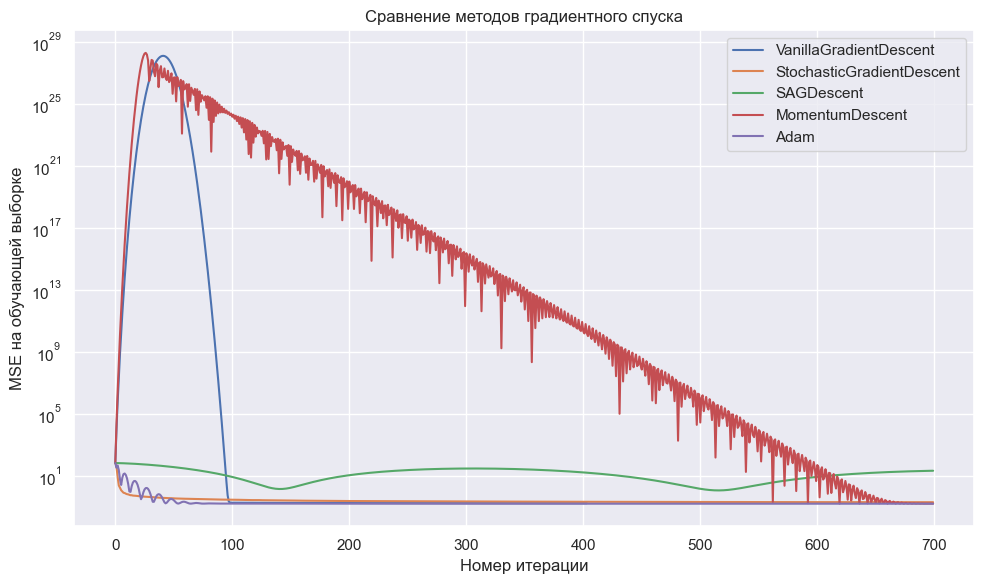

In [32]:
# YOUR CODE HERE (づ｡◕‿‿◕｡)づ
loss_histories = {}

for descent_model in descent_models:
    name = descent_model.__name__
    best_lam = best_lambdas[name]

    lr_schedule = TimeDecayLR(lambda_=best_lam)
    if descent_model == StochasticGradientDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == SAGDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == MomentumDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
    elif descent_model == Adam:
        optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
    else:
        optimizer = descent_model(lr_schedule=lr_schedule)

    model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
    model.fit(X_train, y_train)

    loss_histories[name] = model.loss_history

plt.figure(figsize=(10, 6))
for name, history in loss_histories.items():
    iterations = range(min(len(history), 700))  # так удобнее смотреть, а то критерия сходимости, которые мы изначально ставили, не особо получается достигнуть
    plt.plot(iterations, history[:700], label=name)

plt.xlabel('Номер итерации')
plt.ylabel('MSE на обучающей выборке')
plt.title('Сравнение методов градиентного спуска')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()

## Задание 6. Стохастический градиентный спуск и размер батча (1 балл)

В этом задании вам предстоит исследовать влияние размера батча на работу стохастического градиентного спуска.

* Сделайте по несколько запусков (например, $k = 10$) стохастического градиентного спуска на обучающей выборке для каждого размера батча из перебираемого списка. Замерьте время в секундах и количество итераций до сходимости. Посчитайте среднее этих значений для каждого размера батча.
* Постройте график зависимости количества шагов до сходимости от размера батча. _(под сходимостью понимается достижение критерия останова)_
* Постройте график зависимости времени до сходимости от размера батча.

Посмотрите на получившиеся результаты. Какие выводы можно сделать про подбор размера батча для стохастического градиентного спуска?

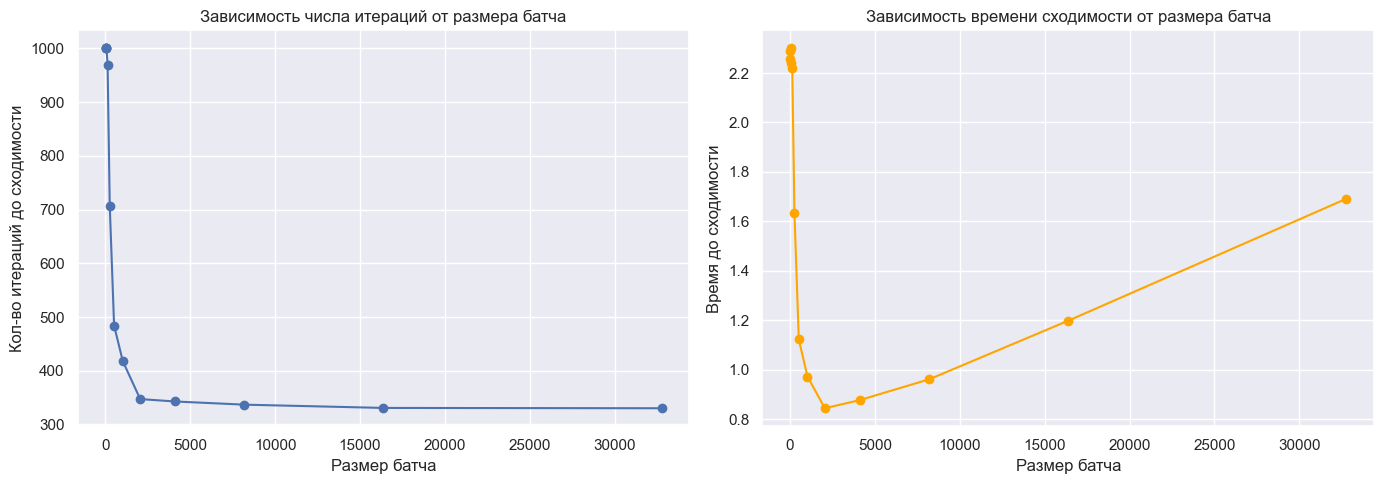

In [35]:
# YOUR CODE HERE (ง •̀_•́)ง
import time


best_lambda_sgd = best_lambdas['StochasticGradientDescent']

batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
num_runs = 10
tolerance = 1e-6
max_iter = 1000

results = {bs: {'iterations': [], 'time': []} for bs in batch_sizes}

for bs in batch_sizes:
    for run in range(num_runs):
        lr_schedule = TimeDecayLR(lambda_=best_lambda_sgd)
        optimizer = StochasticGradientDescent(
            lr_schedule=lr_schedule,
            batch_size=bs,
            tolerance=tolerance,
            max_iter=max_iter
        )
        model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())

        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start_time

        iterations = len(model.loss_history) - 1
        results[bs]['iterations'].append(iterations)
        results[bs]['time'].append(elapsed)

avg_results = {}
for bs in batch_sizes:
    avg_iter = np.mean(results[bs]['iterations'])
    avg_time = np.mean(results[bs]['time'])
    avg_results[bs] = {'avg_iterations': avg_iter, 'avg_time': avg_time}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(batch_sizes, [avg_results[bs]['avg_iterations'] for bs in batch_sizes], marker='o')
ax1.set_xlabel('Размер батча')
ax1.set_ylabel('Кол-во итераций до сходимости')
ax1.set_title('Зависимость числа итераций от размера батча')
ax1.grid(True)

ax2.plot(batch_sizes, [avg_results[bs]['avg_time'] for bs in batch_sizes], marker='o', color='orange')
ax2.set_xlabel('Размер батча')
ax2.set_ylabel('Время до сходимости')
ax2.set_title('Зависимость времени сходимости от размера батча')
ax2.grid(True)

plt.tight_layout()
plt.show()

**Выводы:**

По первому графику:

1. Логично, что должно убывать, поскольку чем больше размер батча, тем точнее мы двигаемся, а значит нужно меньшее кол-во шагов для достижения оптимума. 

2. Насчет скорости убывания можно сказать, что при увеличении батча с маленького размера на больший (в 2 раза), то точность вырастет гораздо больше, поскольку наши движения начинают учитывать гораздо больше градиентов, чем до этого (в начале мы вообще почти ничего не учитываем, а просто смотри на малое кол-во градиентов). В ситуации, когда батч уже большой доп прирост от новых градиентов уже не такой значительный, поскольку правильная траектория движения уже считай сформирована и это незначительные корректировки

По второму:

Ну, все довольно логично. Сначала время убывает, потому что мы делаем меньше шагов -> быстрее сходимся. Сложность подсчетов не особо возрастает в самом начале, ибо считаем довольно мало градиентов. Потом уже эффект от кол-ва итераций становися слабее и мы просто бессмысленно увеличиваем батчи, значительно усложняя расчеты -> дольше считать каждый шаг -> растет время на сходимость

## Задание 7. Регуляризация (0.5 балла)

В этом задании вам предстоит исследовать влияние регуляризации на работу различных методов градиентного спуска. Напомним, регуляризация – это добавка к функции потерь, которая штрафует за норму весов. Мы будем использовать $L_2$-регуляризацию, таким образом функция потерь приобретает следующий вид:

$$
    Q(w) = \dfrac{1}{\ell} \sum\limits_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} \| w \|^2
$$

Допишите класс `linear_regression.L2Regularization`, следуя интерфейсу и докуметации.

Используя регуляризованный лосс в эксприментах, найдите лучшие параметры обучения с регуляризацией аналогично 5 заданию. Будем подбирать длину шага $\lambda$ (`lambda_`) и коэффициент регуляризации $\mu$ (`mu`).

Сравните для каждого метода результаты с регуляризацией и без регуляризации (нужно опять сохранить ошибку и качество по метрике $R^2$ на обучающей и тестовой выборках и количество итераций до сходимости).

Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации (всего должно получиться 5 графиков).

Посмотрите на получившиеся результаты. Какие можно сделать выводы, как регуляризация влияет на сходимость? Как изменилось качество на обучающей выборке? На тестовой? Чем вы можете объяснить это?

In [37]:
# YOUR CODE HERE (✿◠‿◠)
from linear_regression import L2Regularization


y_train = y_train.values if isinstance(y_train, pd.Series) else y_train
y_val = y_val.values if isinstance(y_val, pd.Series) else y_val
y_test = y_test.values if isinstance(y_test, pd.Series) else y_test

np.random.seed(69)

lambda_values = np.logspace(-5, 0.5, 10)  # я все понимаю, но это ту мач что-то перебирать (если увеличим кол-во значений, то все будет хорошо, но я на такое самоубийство не пойду)
mu_values = np.logspace(-5, 0.5, 10)

best_params_reg = {}
final_results_reg = {}
loss_histories_reg = {}

for descent_model in descent_models:
    name = descent_model.__name__
    print(f"\nПодбор lambda и mu для {name} с регуляризацией")
    best_val_loss = np.inf
    best_lam = None
    best_mu = None

    for lam in lambda_values:  # смерть
        for mu in mu_values:
            lr_schedule = TimeDecayLR(lambda_=lam)
            optimizer = descent_model(lr_schedule=lr_schedule, max_iter=max_iter)

            core_loss = MSELoss()
            reg_loss = L2Regularization(core_loss, mu_rate=mu)

            model = CustomLinearRegression(optimizer=optimizer, loss_function=reg_loss)
            model.fit(X_train, y_train)

            if np.any(np.isnan(model.w)) or np.any(np.isinf(model.w)):
                val_loss = np.inf
            else:
                y_val_pred = model.predict(X_val)
                if np.any(np.isnan(y_val_pred)) or np.any(np.isinf(y_val_pred)):
                    val_loss = np.inf
                else:
                    val_loss = mean_squared_error(y_val, y_val_pred)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_lam = lam
                best_mu = mu

    best_params_reg[name] = (best_lam, best_mu)
    print(f"Лучшие: lambda = {best_lam:.6f}, mu = {best_mu:.6f}, val MSE = {best_val_loss:.6f}")

    lr_schedule = TimeDecayLR(lambda_=best_lam)
    optimizer = descent_model(lr_schedule=lr_schedule, max_iter=1000)
    reg_loss = L2Regularization(MSELoss(), mu_rate=best_mu)
    model = CustomLinearRegression(optimizer=optimizer, loss_function=reg_loss)
    model.fit(X_train, y_train)

    loss_histories_reg[name] = model.loss_history
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    final_results_reg[name] = {
        'best_lambda': best_lam,
        'best_mu': best_mu,
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'iterations': len(model.loss_history) - 1
    }


Подбор lambda и mu для VanillaGradientDescent с регуляризацией
Лучшие: lambda = 0.774264, mu = 0.000010, val MSE = 0.189854

Подбор lambda и mu для StochasticGradientDescent с регуляризацией
Лучшие: lambda = 0.189574, mu = 0.011365, val MSE = 0.211252

Подбор lambda и mu для SAGDescent с регуляризацией
Лучшие: lambda = 3.162278, mu = 0.002783, val MSE = 1.155102

Подбор lambda и mu для MomentumDescent с регуляризацией
Лучшие: lambda = 0.774264, mu = 0.000010, val MSE = 0.172358

Подбор lambda и mu для Adam с регуляризацией
Лучшие: lambda = 3.162278, mu = 0.000010, val MSE = 0.167015


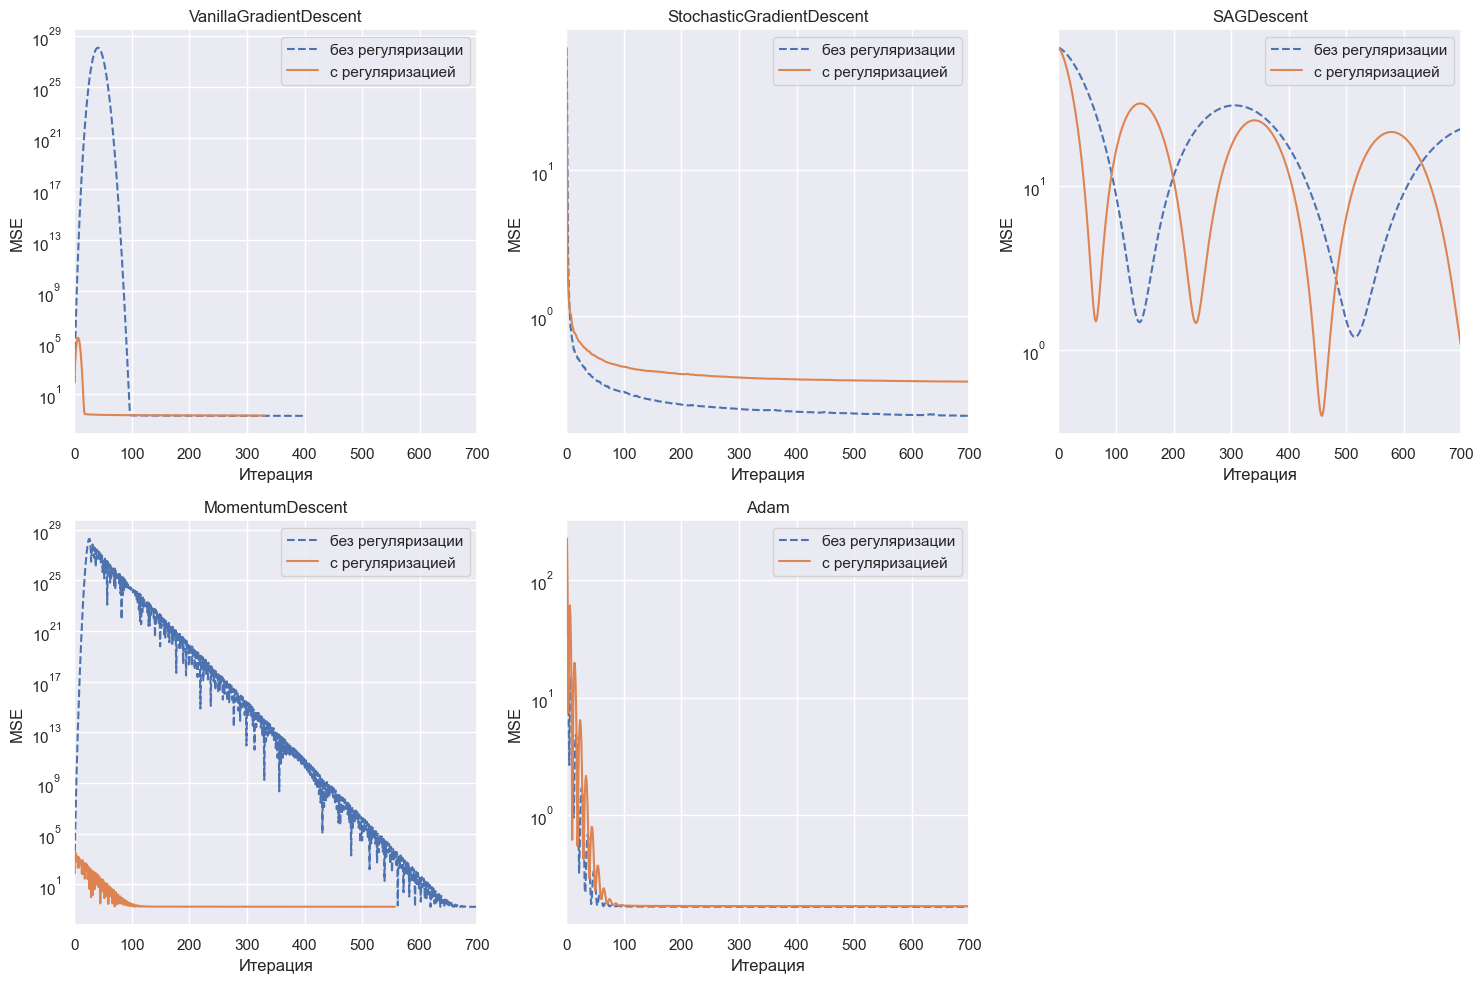

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, name in enumerate([m.__name__ for m in descent_models]):
    ax = axes[i]
    ax.plot(range(min(len(loss_histories[name]), 700)), loss_histories[name][:700], label='без регуляризации', linestyle='--')
    ax.plot(range(min(len(loss_histories_reg[name]), 700)), loss_histories_reg[name][:700], label='с регуляризацией')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('MSE')
    ax.set_yscale('log')
    ax.set_title(name)
    ax.legend()
    ax.grid(True)
    ax.set_xlim(0, 700)
axes[5].axis('off')
plt.tight_layout()
plt.show()

**Вывод:**
Буду писать выводы так, будто графики хорошие и там 100 стоят в переборе. Это плохо подтверждается на данных, поскольку в версии без регуляризации я делал гораздо больший перебор -> лучше точность модели, а тут я очень посредственно перебирал лямбды и получил такую себе модель, но времени для лучшего перебора нет (да и ресурсов пк тоже).


1. MSE на обучающей выборке с регуляризацией, выше, чем без неё. Это ожидаемо, поскольку регуляризация ограничивает гибкость модели, не позволяя ей подогнаться под шум и подгона под данные не будет в той же мере, что без регуляризации. Модель становится менее склонной к переобучению, но платит за это некоторым увеличением ошибки на тренировочном множестве

2. На тестовой ниже, поскольку более гибкая модель и ниже переобучение. Достигается за счет системы штрафов для больших весов -> модель ищет решение на маленьких весах -> более устойчива к скачкам в признаках -> более гибкая в общем случае, но менее точная на обучающей выборке

3. Сама сходимость должна быть менее волатильной поскольку модель не так сильно реагирует на изменения в конкретных признаках

4. Скорость сходимости по идее не должна меняться, может только если вырастет (немного), поскольку больше считать. Но на некоторых графиках почему-то скорость выросла значительно. Полагаю что виноваты параметры, которые не самые оптимальные, но быстрые



## Задание 8. Альтернативные функции потерь (1 балл)

В этом задании вам предстоит использовать другую функцию потерь для нашей задачи регрессии. В качестве функции потерь мы выбрали **LogCosh** и **HuberLoss**:

$$
    L(y, a)
    =
    \log\left(\cosh(a - y)\right).
$$

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
   \frac{1}{2} (a_i - y_i)^2, & \text{если } |a_i - y_i| < \delta, \\
   \delta \cdot |a_i - y_i| - \frac{1}{2} \delta^2, & \text{если } |a_i - y_i| \geq \delta,
\end{cases}
$$

Самостоятельно продифференцируйте данные функции потерь чтобы найти их градиенты _(требуется показать не только результат, но и промежуточные вычисления)_:

**Решение:**

1. Градиент функции потерь LogCosh
$L_{\text{logcosh}}(a, y) = \log(\cosh(a - y))$

$r = a - y = \mathbf{w}^\top \mathbf{x} - y$

$L = \log(\cosh r)$

$\frac{d}{dr} \cosh r = \sinh r$

$\frac{d}{dr} \log(\cosh r) = \frac{\sinh r}{\cosh r} = \tanh r$

$\frac{\partial L}{\partial r} = \tanh r$

$\frac{\partial L}{\partial \mathbf{w}} = \frac{\partial L}{\partial r} \cdot \frac{\partial r}{\partial \mathbf{w}} = \tanh r \cdot \mathbf{x}$

$\nabla_{\mathbf{w}} L_{\text{logcosh}} = \tanh(\mathbf{w}^\top \mathbf{x} - y) , \mathbf{x}$

2. Градиент функции потерь Huber
$L_{\text{huber}}(a, y) = \begin{cases} \frac12 (a - y)^2, & |a - y| < \delta \ \delta |a - y| - \frac12 \delta^2, & |a - y| \ge \delta \end{cases}$

$r = a - y = \mathbf{w}^\top \mathbf{x} - y$

При $|r| < \delta$: $L = \frac12 r^2$, $\displaystyle \frac{dL}{dr} = r$

При $r \ge \delta$: $L = \delta r - \frac12 \delta^2$, $\displaystyle \frac{dL}{dr} = \delta$

При $r \le -\delta$: $L = -\delta r - \frac12 \delta^2$, $\displaystyle \frac{dL}{dr} = -\delta$

Таким образом, $\displaystyle \frac{\partial L}{\partial r} = \begin{cases} r, & |r| < \delta \ \delta, & r \ge \delta \ -\delta, & r \le -\delta \end{cases}$

$\displaystyle \frac{\partial L}{\partial r} = \operatorname{clip}(r, -\delta, \delta)$

$\displaystyle \frac{\partial L}{\partial \mathbf{w}} = \frac{\partial L}{\partial r} \cdot \frac{\partial r}{\partial \mathbf{w}} = \operatorname{clip}(r, -\delta, \delta) , \mathbf{x}$

$\nabla_{\mathbf{w}} L_{\text{huber}} = \operatorname{clip}(\mathbf{w}^\top \mathbf{x} - y, -\delta, \delta) , \mathbf{x}$


**Гуглил + просил гпт в тех перевести (в таком кривом формате, потому что не смог сам нормально затехать) + просил гпт док-во оформить**

Программно реализуйте функции потерь и их градиенты для LogCosh и HuberLoss в файле `linear_regression.py`. После этого обучите все пять методов градиентного спуска (без регуляризации) с этими лоссами аналогично заданию 5 и сравните качество с результатами из задания 5, где использовался MSE.

Имплементировать эти функции потерь необходимо при помощи наследования от `linear_regression.LossFunction` и имплементирования всех абстрактных методов. Аналитическое решение для этих функций выводить и имплементировать не требуется.



In [47]:
from linear_regression import LogCoshLoss, HuberLoss


lambda_values = np.logspace(-5, 0.5, 20)  # пощадите, не хочу снова 100 значений, я уже начинаю жалеть, что взял их выше

best_lambdas_logcosh = {}
final_results_logcosh = {}

for descent_model in descent_models:
    name = descent_model.__name__
    print(f"\nПодбор lambda для {name} с LogCoshLoss")
    best_val_loss = np.inf
    best_lam = None

    for lam in lambda_values:
        lr_schedule = TimeDecayLR(lambda_=lam)  # понимаю, что можно просто написать optimizer = descent_model(lr_schedule=lr_schedule) и не париться, но я просто копирую код из старых заданий, не обращаем внимания
        if descent_model == StochasticGradientDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
        elif descent_model == SAGDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
        elif descent_model == MomentumDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
        elif descent_model == Adam:
            optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
        else:
            optimizer = descent_model(lr_schedule=lr_schedule)

        model = CustomLinearRegression(optimizer=optimizer, loss_function=LogCoshLoss())
        model.fit(X_train, y_train)

        if np.any(np.isnan(model.w)) or np.any(np.isinf(model.w)):
            val_loss = np.inf
        else:
            y_val_pred = model.predict(X_val)
            if np.any(np.isnan(y_val_pred)) or np.any(np.isinf(y_val_pred)):
                val_loss = np.inf
            else:
                val_loss = mean_squared_error(y_val, y_val_pred)  # поменяли метрику, но ошибку считаем в MSE, чтобы легко сравнить модели

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_lam = lam

    best_lambdas_logcosh[name] = best_lam
    print(f"Лучшая lambda для {name}: {best_lam:.6f} (val MSE = {best_val_loss:.6f})")

    lr_schedule = TimeDecayLR(lambda_=best_lam)
    if descent_model == StochasticGradientDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == SAGDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == MomentumDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
    elif descent_model == Adam:
        optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
    else:
        optimizer = descent_model(lr_schedule=lr_schedule)

    model = CustomLinearRegression(optimizer=optimizer, loss_function=LogCoshLoss())
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    final_results_logcosh[name] = {
        'best_lambda': best_lam,
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'iterations': len(model.loss_history) - 1
    }

df_logcosh = pd.DataFrame(final_results_logcosh).T
print("\nРезультаты для LogCoshLoss:")
print(df_logcosh.round(6))


best_lambdas_huber = {}
final_results_huber = {}

for descent_model in descent_models:
    name = descent_model.__name__
    print(f"\nПодбор lambda для {name} с HuberLoss")
    best_val_loss = np.inf
    best_lam = None

    for lam in lambda_values:
        lr_schedule = TimeDecayLR(lambda_=lam)
        if descent_model == StochasticGradientDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
        elif descent_model == SAGDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
        elif descent_model == MomentumDescent:
            optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
        elif descent_model == Adam:
            optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
        else:
            optimizer = descent_model(lr_schedule=lr_schedule)

        model = CustomLinearRegression(optimizer=optimizer, loss_function=HuberLoss(delta=1.0))  # просто решил такой сделать
        model.fit(X_train, y_train)

        if np.any(np.isnan(model.w)) or np.any(np.isinf(model.w)):
            val_loss = np.inf
        else:
            y_val_pred = model.predict(X_val)
            if np.any(np.isnan(y_val_pred)) or np.any(np.isinf(y_val_pred)):
                val_loss = np.inf
            else:
                val_loss = mean_squared_error(y_val, y_val_pred)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_lam = lam

    best_lambdas_huber[name] = best_lam
    print(f"Лучшая lambda для {name}: {best_lam:.6f} (val MSE = {best_val_loss:.6f})")

    lr_schedule = TimeDecayLR(lambda_=best_lam)
    if descent_model == StochasticGradientDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == SAGDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == MomentumDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
    elif descent_model == Adam:
        optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
    else:
        optimizer = descent_model(lr_schedule=lr_schedule)

    model = CustomLinearRegression(optimizer=optimizer, loss_function=HuberLoss(delta=1.0))
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    final_results_huber[name] = {
        'best_lambda': best_lam,
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'iterations': len(model.loss_history) - 1
    }

df_huber = pd.DataFrame(final_results_huber).T
print("\nРезультаты для HuberLoss:")
print(df_huber.round(6))


comparison = {}
for method in [m.__name__ for m in descent_models]:
    row = {
        'MSE_test_mse': final_results[method]['test_mse'],
        'MSE_test_r2': final_results[method]['test_r2'],
        'LogCosh_test_mse': final_results_logcosh[method]['test_mse'],
        'LogCosh_test_r2': final_results_logcosh[method]['test_r2'],
        'Huber_test_mse': final_results_huber[method]['test_mse'],
        'Huber_test_r2': final_results_huber[method]['test_r2'],
    }
    comparison[method] = row

df_comp = pd.DataFrame(comparison).T
print(df_comp.round(6))


Подбор lambda для VanillaGradientDescent с LogCoshLoss
Лучшая lambda для VanillaGradientDescent: 3.162278 (val MSE = 0.185407)

Подбор lambda для StochasticGradientDescent с LogCoshLoss
Лучшая lambda для StochasticGradientDescent: 3.162278 (val MSE = 0.181951)

Подбор lambda для SAGDescent с LogCoshLoss
Лучшая lambda для SAGDescent: 3.162278 (val MSE = 6.607655)

Подбор lambda для MomentumDescent с LogCoshLoss
Лучшая lambda для MomentumDescent: 3.162278 (val MSE = 0.172119)

Подбор lambda для Adam с LogCoshLoss
Лучшая lambda для Adam: 0.833782 (val MSE = 0.167841)

Результаты для LogCoshLoss:
                           best_lambda  train_mse  test_mse   test_r2  \
VanillaGradientDescent        3.162278   0.182258  0.186597  0.819498   
StochasticGradientDescent     3.162278   0.180958  0.184993  0.821049   
SAGDescent                    3.162278   6.694756  6.640816 -5.423910   
MomentumDescent               3.162278   0.169850  0.173217  0.832441   
Adam                          0.83

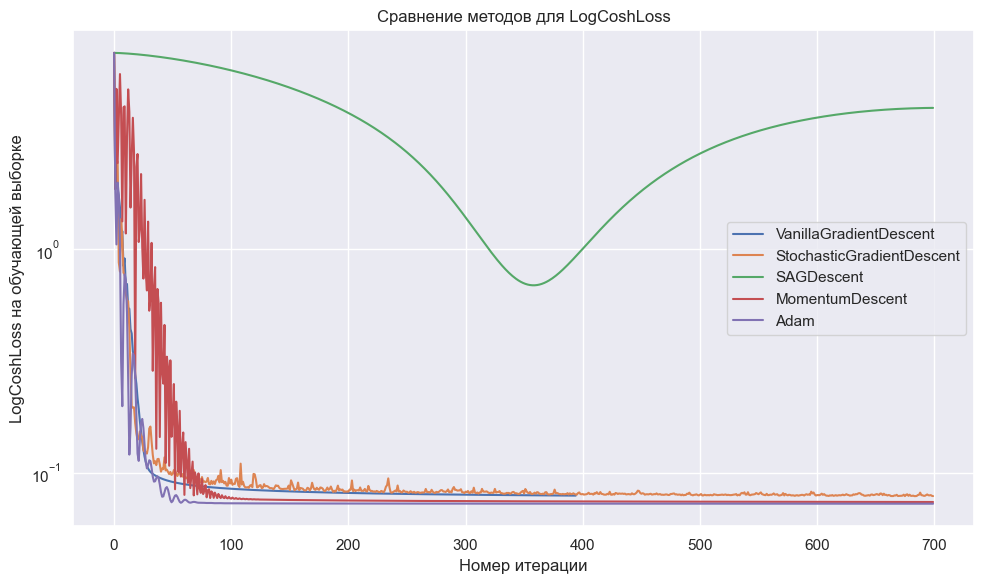

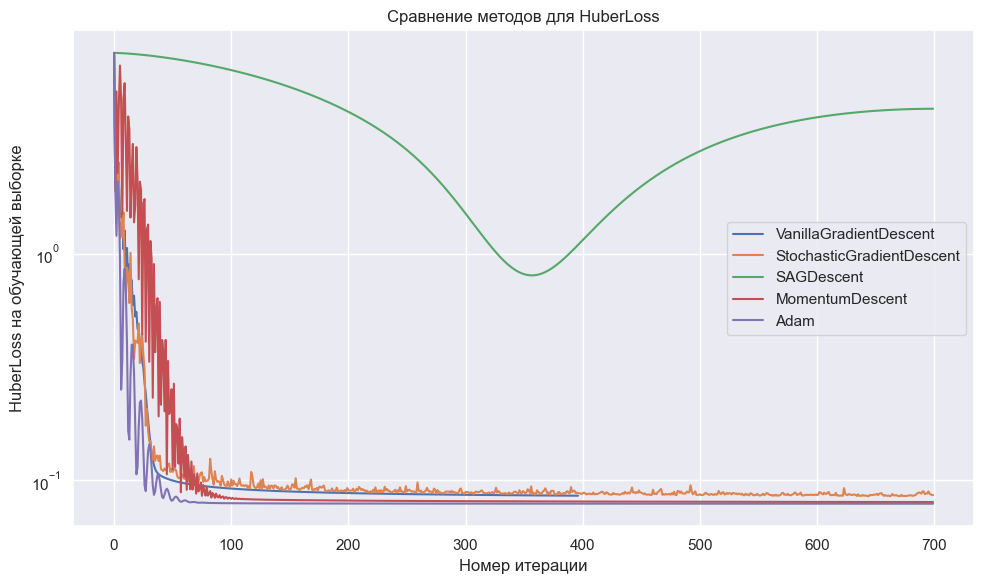

In [48]:
loss_histories_logcosh = {}

for descent_model in descent_models:
    name = descent_model.__name__
    best_lam = best_lambdas_logcosh[name]

    lr_schedule = TimeDecayLR(lambda_=best_lam)
    if descent_model == StochasticGradientDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == SAGDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == MomentumDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
    elif descent_model == Adam:
        optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
    else:
        optimizer = descent_model(lr_schedule=lr_schedule)

    model = CustomLinearRegression(optimizer=optimizer, loss_function=LogCoshLoss())
    model.fit(X_train, y_train)

    loss_histories_logcosh[name] = model.loss_history

plt.figure(figsize=(10, 6))
for name, history in loss_histories_logcosh.items():
    iterations = range(min(len(history), 700))
    plt.plot(iterations, history[:700], label=name)

plt.xlabel('Номер итерации')
plt.ylabel('LogCoshLoss на обучающей выборке')
plt.title('Сравнение методов для LogCoshLoss')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()


loss_histories_huber = {}

for descent_model in descent_models:
    name = descent_model.__name__
    best_lam = best_lambdas_huber[name]

    lr_schedule = TimeDecayLR(lambda_=best_lam)
    if descent_model == StochasticGradientDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == SAGDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, batch_size=32)
    elif descent_model == MomentumDescent:
        optimizer = descent_model(lr_schedule=lr_schedule, beta=0.9)
    elif descent_model == Adam:
        optimizer = descent_model(lr_schedule=lr_schedule, beta1=0.9, beta2=0.999, eps=1e-8)
    else:
        optimizer = descent_model(lr_schedule=lr_schedule)

    model = CustomLinearRegression(optimizer=optimizer, loss_function=HuberLoss(delta=1.0))
    model.fit(X_train, y_train)

    loss_histories_huber[name] = model.loss_history

plt.figure(figsize=(10, 6))
for name, history in loss_histories_huber.items():
    iterations = range(min(len(history), 700))
    plt.plot(iterations, history[:700], label=name)

plt.xlabel('Номер итерации')
plt.ylabel('HuberLoss на обучающей выборке')
plt.title('Сравнение методов для HuberLoss')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()

Резы +- схожие, но нужно на больших значениях обучать в идеале, чтобы сравнить. SAGD точно не сойдется, пока я не пихну 100+ значений для перебора. Мне кажется эти две метрики тут лучше себя показывают, если все переводить в MSE в самом конце, но опять-таки нужно на тех же значениях (по кол-ву) обучать в идеале

Графики делал с гпт, чтобы было проще. Довольно неплохо справляется с этим дипсик + легко редачить под свой лад уже предложенный код

За дублирование кода извиняюсь, просто боюсь каждый раз менять, а то подозрительно будет выглядеть

### Кулинарно-социализационный бонус. (0.5 балла)

Как мы знаем, в феврале зима уже не объяснение, а обстоятельство непреодолимой силы - и лучший способ спорить с ней это поделиться теплом с друзьями и близкими. Выберите рецепт, который соответствует вашему настроению, приготовьте выбранное блюдо и угостите хотя бы одного человека им. Кратко опишите ваши впечатления, прикрепите рецепт и фотографии блюда и довольного гостя.

Вместо 1000 слов

https://drive.google.com/file/d/1F9rrgBaumtlqsbcF3We5kCapmJV_Cjf2/view?usp=sharing